# Ayudantía 10 — Diseño Factorial Fraccionado

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/Ayudantias/Ayudantia10_DisenoFactorialFraccionadoYSuperficieDeRespuesta.ipynb)

**IIQ3402 – Diseño Estadístico, Optimización y Análisis Multivariado**  
Profesor: Pedro Saa | Ayudante: Gabriel Miranda

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from itertools import combinations

---
# Parte 1: Diseño Factorial $2^4$ en Bloques

## Concepto de Bloqueo por Contraste

En un diseño factorial completo, puede haber fuentes de variabilidad **no controlada** (distintos lotes de reactivos, diferentes operadores, cambios de turno) que afecten la respuesta sin ser de interés. Si no las controlamos, inflan el $MS_E$ y reducen la potencia del test.

La estrategia de **bloqueo por contraste** divide las corridas en grupos homogéneos (bloques) usando una función lineal de los factores:

$$L = x_A + x_B + x_C + x_D \pmod{2}$$

donde $x_j \in \{0, 1\}$ indica si el factor $j$ está en su nivel alto.

| $L \pmod{2}$ | Nº de factores en nivel alto | Bloque |
|:---:|:---:|:---:|
| 0 (par)   | par   | Bloque I  |
| 1 (impar) | impar | Bloque II |

> **Costo:** la interacción usada como contraste queda **confundida** con el bloque y no puede estimarse de forma independiente. Por eso se elige la interacción de **mayor orden** (presumiblemente nula, por el principio de dispersión de efectos).

In [38]:
# Datos del diseño 2^4 (Ejemplo 6.2, Montgomery 2017)
# Factores codificados en {-1, +1}; respuesta y
data_frame1 = pd.DataFrame({
    "A1": [-1,  1, -1, -1, -1,  1,  1, -1,  1, -1, -1,  1, -1,  1,  1,  1],
    "B1": [-1, -1,  1, -1, -1,  1, -1,  1, -1,  1, -1,  1,  1, -1,  1,  1],
    "C1": [-1, -1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1],
    "D1": [-1, -1, -1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1],
    "y":  [25, 71, 48, 68, 43, 45, 40, 60, 80, 25, 55, 65, 70, 86, 104, 76]
})
display(data_frame1)

,A1,B1,C1,D1,y
0,-1,-1,-1,-1,25
1,1,-1,-1,-1,71
2,-1,1,-1,-1,48
3,-1,-1,1,-1,68
4,-1,-1,-1,1,43
5,1,1,-1,-1,45
6,1,-1,1,-1,40
7,-1,1,1,-1,60
8,1,-1,-1,1,80
9,-1,1,-1,1,25


---
## a) Demostración: $ABCD$ se confunde con los bloques

> Demuestre que a partir del contraste $L = x_A + x_B + x_C + x_D$ el efecto $ABCD$ se confunde con los bloques generados.

**Idea clave:** el signo del producto $A \cdot B \cdot C \cdot D$ en la matriz de Yates coincide exactamente con la asignación de bloques dada por $L$.

- Número **par** de factores en $+1$ → $ABCD = +1$ → $L \equiv 0 \pmod{2}$ → **Bloque I**
- Número **impar** de factores en $+1$ → $ABCD = -1$ → $L \equiv 1 \pmod{2}$ → **Bloque II**

La tabla de contrastes (columna $ABCD$ y bloque) confirma esto:

| Run  | A  | B  | C  | D  | ABCD | Bloque |
|------|----|----|----|----|:----:|:------:|
| (1)  | -1 | -1 | -1 | -1 | +1   | I      |
| a    | +1 | -1 | -1 | -1 | -1   | II     |
| b    | -1 | +1 | -1 | -1 | -1   | II     |
| ab   | +1 | +1 | -1 | -1 | +1   | I      |
| c    | -1 | -1 | +1 | -1 | -1   | II     |
| ac   | +1 | -1 | +1 | -1 | +1   | I      |
| bc   | -1 | +1 | +1 | -1 | +1   | I      |
| abc  | +1 | +1 | +1 | -1 | -1   | II     |
| d    | -1 | -1 | -1 | +1 | -1   | II     |
| ad   | +1 | -1 | -1 | +1 | +1   | I      |
| bd   | -1 | +1 | -1 | +1 | +1   | I      |
| abd  | +1 | +1 | -1 | +1 | -1   | II     |
| cd   | -1 | -1 | +1 | +1 | +1   | I      |
| acd  | +1 | -1 | +1 | +1 | -1   | II     |
| bcd  | -1 | +1 | +1 | +1 | -1   | II     |
| abcd | +1 | +1 | +1 | +1 | +1   | I      |

**Conclusión:** estimar el "efecto del bloque" (diferencia de medias entre Bloque I y Bloque II) equivale exactamente a estimar el efecto $ABCD$. Son **inseparables** → están confundidos.

> **¿Por qué $ABCD$ es la mejor elección?** Por el principio de dispersión de efectos, las interacciones de cuarto orden son prácticamente siempre nulas. Confundirlas con el bloque no implica pérdida de información relevante.

---
## b) Estimación del Efecto de Bloque

> Estime el efecto del bloqueo generado por el contraste. Interprete su magnitud en relación a la variabilidad experimental.

El efecto del bloque y su suma de cuadrados se calculan como:

$$\hat{E}_{\text{bloque}} = \bar{y}_{B_I} - \bar{y}_{B_{II}}$$

$$SS_{\text{bloque}} = \frac{y_{B_I}^2 + y_{B_{II}}^2}{n/2} - \frac{y_{..}^2}{n}$$

donde $y_{B_I}$ y $y_{B_{II}}$ son las sumas de las respuestas en cada bloque y $n = 16$.

In [39]:
# Asignar bloque según el signo de A*B*C*D
# ABCD = +1 (par de +1s) → Bloque I  (codificado como 1)
# ABCD = -1 (impar de +1s) → Bloque II (codificado como 0)
data_frame1['Block'] = (data_frame1['A1'] * data_frame1['B1']
                        * data_frame1['C1'] * data_frame1['D1'])
data_frame1['Block'] = data_frame1['Block'].apply(lambda x: 1 if x == 1 else 0)

display(data_frame1[['A1','B1','C1','D1','y','Block']])

,A1,B1,C1,D1,y,Block
0,-1,-1,-1,-1,25,1
1,1,-1,-1,-1,71,0
2,-1,1,-1,-1,48,0
3,-1,-1,1,-1,68,0
4,-1,-1,-1,1,43,0
5,1,1,-1,-1,45,1
6,1,-1,1,-1,40,1
7,-1,1,1,-1,60,1
8,1,-1,-1,1,80,1
9,-1,1,-1,1,25,1


In [40]:
# Efecto del bloque: diferencia de medias entre bloques
block_effect = (data_frame1[data_frame1['Block'] == 1]['y'].mean()
              - data_frame1[data_frame1['Block'] == 0]['y'].mean())
print(f"Efecto del bloque (ȳ_BI - ȳ_BII): {block_effect:.4f}")

# Suma de cuadrados del bloque
SS_block = (
    (data_frame1[data_frame1['Block'] == 1]['y'].sum()**2 +
     data_frame1[data_frame1['Block'] == 0]['y'].sum()**2) / 8
) - (data_frame1['y'].sum()**2 / 16)
print(f"SS Bloque:                         {SS_block:.4f}")

# Suma de cuadrados total
Total_SS = np.sum(data_frame1['y']**2) - (data_frame1['y'].sum()**2 / 16)
print(f"SS Total:                          {Total_SS:.4f}")

pct = SS_block / Total_SS * 100
print(f"\nEl bloque explica el {pct:.2f}% de la variabilidad total.")

Efecto del bloque (ȳ_BI - ȳ_BII): -18.6250
SS Bloque:                         1387.5625
SS Total:                          7110.9375

El bloque explica el 19.51% de la variabilidad total.


**Interpretación:**

- El efecto del bloque es $-18.625$: el Bloque I tiene en promedio $18.6$ unidades **más** que el Bloque II.
- El bloque explica el **~19.5%** de la variabilidad total — una fracción considerable.
- Si no hubiéramos bloqueado, esta variabilidad habría inflado el $MS_E$, dificultando la detección de los efectos de los factores A, B, C, D.

> **Conclusión:** el bloqueo fue una decisión correcta. Se debe incluir el bloque como covariable en el modelo para recuperar esos grados de libertad.

---
## c) Regresión Lineal y Selección de Variables

> Mediante regresión lineal, estime los efectos de cada uno de los factores principales e interacciones significativas. ¿Cuál(es) parecen relevantes?

Con solo 1 réplica y 16 corridas, el **modelo saturado** (todos los EP + 2FI + 3FI, excluyendo $ABCD$ confundida con el bloque) tiene $\mathrm{df}_{\text{res}} = 1$, lo que hace los errores estándar muy grandes y los p-valores poco confiables.

**Estrategia:** ajustar el modelo saturado para obtener los coeficientes estimados, y luego usar un **gráfico de Pareto** para identificar los efectos de mayor magnitud.

In [41]:
# Modelo saturado: todos los efectos posibles excepto ABCD (confundida con el bloque)
# Sintaxis: A1*B1*C1*D1 genera automáticamente EP, 2FI, 3FI e interacción 4FI
# Se resta A1:B1:C1:D1 porque está confundida con el bloque
model = ols('y ~ A1 * B1 * C1 * D1 - A1:B1:C1:D1', data=data_frame1).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                 -1.927
Method:                 Least Squares   F-statistic:                    0.2946
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.913
Time:                        15:58:23   Log-Likelihood:                -58.405
No. Observations:                  16   AIC:                             146.8
Df Residuals:                       1   BIC:                             158.4
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.0625      9.313      6.450      0.0

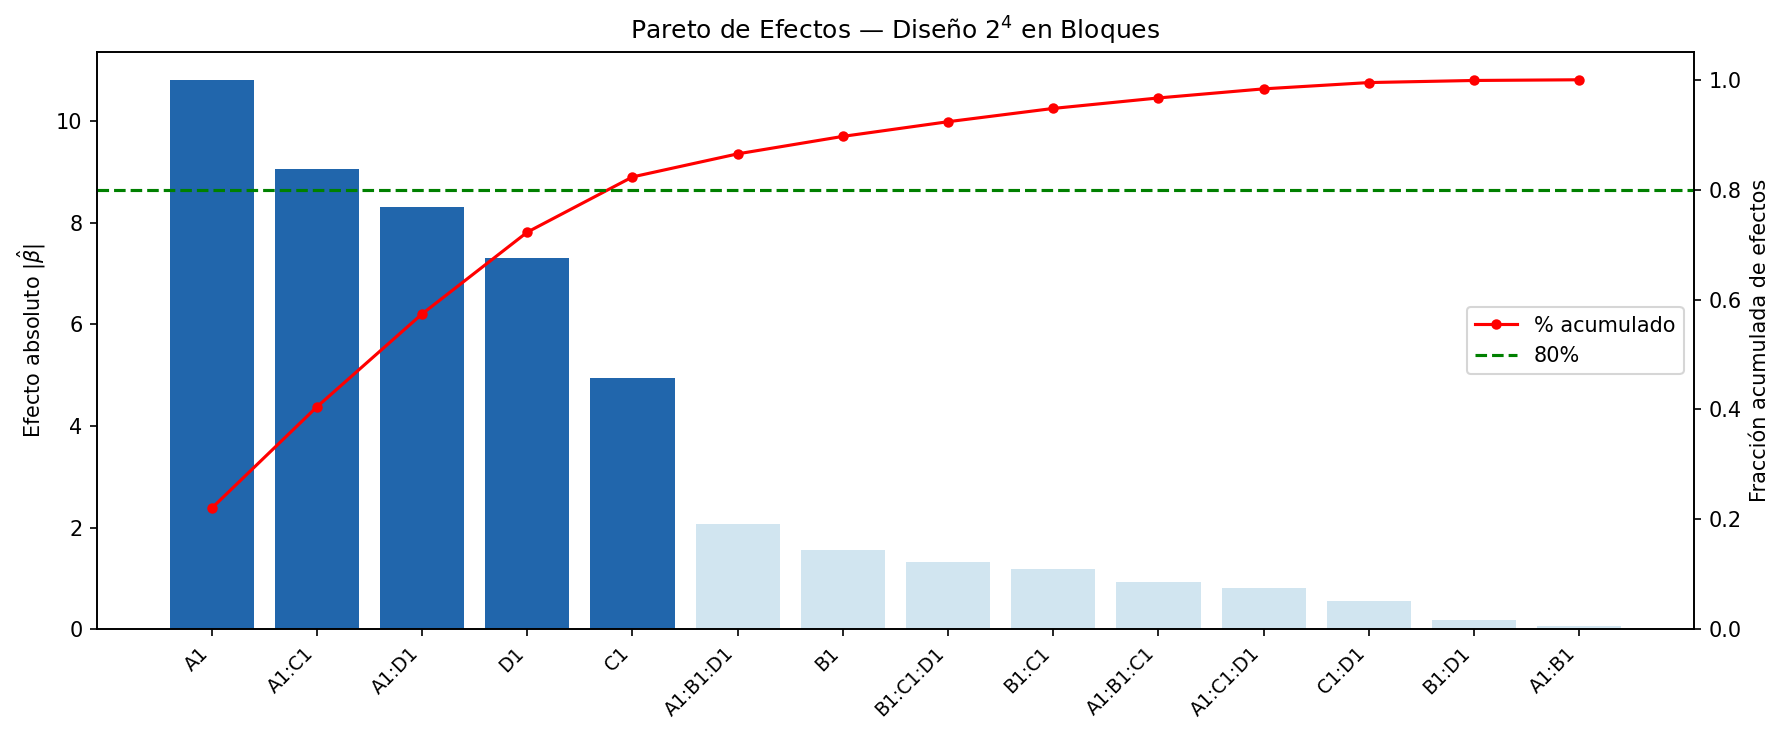

In [42]:
# Gráfico de Pareto de efectos absolutos
# La curva acumulada (eje derecho) ayuda a ver el 'codo' a partir del cual
# los efectos son marginales
abs_params = np.abs(model.params[1:]).sort_values(ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5), dpi=150)

# Color azul intenso para efectos destacados (umbral arbitrario de 4)
colors = ['#2166ac' if v > 4 else '#d1e5f0' for v in abs_params.values]
ax1.bar(range(len(abs_params)), abs_params.values, color=colors)
ax1.set_xticks(range(len(abs_params)))
ax1.set_xticklabels(abs_params.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Efecto absoluto $|\\hat{\\beta}|$')
ax1.set_title('Pareto de Efectos — Diseño $2^4$ en Bloques')

# Curva de Pareto acumulada
ax2 = ax1.twinx()
cum = np.cumsum(abs_params.values) / abs_params.values.sum()
ax2.plot(range(len(abs_params)), cum, 'r-o', ms=4, label='% acumulado')
ax2.axhline(0.80, color='green', ls='--', label='80%')
ax2.set_ylabel('Fracción acumulada de efectos')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

**Interpretación del Pareto:**

El factor $B$ y todas sus interacciones tienen efectos pequeños (< 2.5). Se pueden eliminar del modelo sin perder capacidad explicativa.

---
## d) Reducción del Modelo

> ¿Es posible reducir la cantidad de factores en su modelo? Justifique mediante criterios estadísticos. Genere la nueva estimación del modelo reducido.

A partir del gráfico de Pareto, se elimina $B$ y todas sus interacciones. El modelo reducido incluye:
- Efectos principales: $A$, $C$, $D$
- Interacciones: $A{:}C$, $A{:}D$
- Covariable de bloque

Al eliminar $B$ y sus interacciones (9 términos), se ganan **9 grados de libertad** para el residual → el $MS_E$ es ahora estimable y todos los tests son válidos.

In [43]:
# Modelo reducido: solo efectos significativos + bloque como covariable
ols_red = ols('y ~ A1 + D1 + C1 + A1:C1 + A1:D1 + Block',
              data=data_frame1).fit()
print(ols_red.summary())
print("\n--- ANOVA Tipo II ---")
display(anova_lm(ols_red, typ=2))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     55.37
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.35e-06
Time:                        15:58:24   Log-Likelihood:                -42.395
No. Observations:                  16   AIC:                             98.79
Df Residuals:                       9   BIC:                             104.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     69.3750      1.614     42.983      0.0

,sum_sq,df,F,PR(>F)
A1,1870.5625,1.0,89.757081,0.000006
D1,855.5625,1.0,41.053316,0.000124
C1,390.0625,1.0,18.716761,0.001915
A1:C1,1314.0625,1.0,63.053982,0.000023
A1:D1,1105.5625,1.0,53.049317,0.000046
Block,1387.5625,1.0,66.580806,0.000019
Residual,187.5625,9.0,NaN,NaN


**Interpretación del modelo reducido:**

$$\hat{y} = 69.4 + 10.8\,A + 7.3\,D + 4.9\,C - 9.1\,(AC) + 8.3\,(AD) - 18.6\,\text{Bloque}$$

- **$R^2 = 0.974$**: el modelo explica el 97.4% de la variabilidad total.
- **Todos los efectos son significativos** ($p < 0.01$) con 9 gl residuales.
- La interacción **$A{:}C$ tiene signo negativo**: subir $A$ y $C$ simultáneamente al nivel alto produce un efecto combinado menor que la suma de sus efectos individuales.
- El **bloque** es altamente significativo ($p < 0.001$), confirmando que era necesario controlarlo.

---
---
# Parte 2: Diseño Factorial Fraccionado $2^{5-1}_V$

## Concepto de Fraccionamiento

Cuando $k$ es grande, el número de corridas $2^k$ crece exponencialmente. Un **diseño factorial fraccionado** $2^{k-p}$ usa solo $2^{k-p}$ corridas, sacrificando la estimación de interacciones de alto orden.

**¿Cómo se construye?**  
Se definen $p$ factores adicionales como **productos** de los factores base. Para un $2^{5-1}$:

$$E = ABCD$$

El nivel del factor $E$ en cada corrida queda **determinado** por el producto de los niveles de $A$, $B$, $C$ y $D$.

**Relación definitoria:** multiplicando ambos lados por $E$ (y usando $E^2 = I$):

$$I = ABCDE$$

Esta expresión se llama **relación definitoria** y es el generador fundamental de la estructura de alias del diseño.

In [44]:
# Datos del diseño 2^(5-1) con generador I = ABCDE  (Ejemplo 8.2, Montgomery)
# El factor E = A*B*C*D: verificar que esto se cumple en los datos
df_fraccional_yield = pd.DataFrame({
    "A": [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1],
    "B": [-1, -1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1],
    "C": [-1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1,  1],
    "D": [-1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1],
    "E": [ 1, -1, -1,  1, -1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,  1],
    "Yield": [8, 9, 34, 52, 16, 22, 45, 60, 6, 10, 30, 50, 15, 21, 44, 63]
})

# Verificar que E = A*B*C*D en todas las filas
E_check = df_fraccional_yield['A'] * df_fraccional_yield['B'] * df_fraccional_yield['C'] * df_fraccional_yield['D']
print("Verificado: E = ABCD en todas las corridas.\n")

display(df_fraccional_yield)

Verificado: E = ABCD en todas las corridas.



,A,B,C,D,E,Yield
0,-1,-1,-1,-1,1,8
1,1,-1,-1,-1,-1,9
2,-1,1,-1,-1,-1,34
3,1,1,-1,-1,1,52
4,-1,-1,1,-1,-1,16
5,1,-1,1,-1,1,22
6,-1,1,1,-1,1,45
7,1,1,1,-1,-1,60
8,-1,-1,-1,1,-1,6
9,1,-1,-1,1,1,10


---
## a) Estructura de Alias y Resolución del Diseño

> Determine el alias completo para cada uno de los factores. ¿Qué significa que el diseño tenga resolución V? ¿Qué tipos de efectos pueden interpretarse sin ambigüedad?

### Regla de cálculo de alias

Para encontrar el alias de cualquier efecto $X$, se multiplica por la relación definitoria $I$:

$$[X] = X \cdot I \qquad \text{(letras repetidas se cancelan: } X^2 = I\text{)}$$

### Alias con $I = ABCDE$

**Efectos principales (EP):**

| Efecto | Cálculo | Alias |
|:------:|:-------:|:-----:|
| $[E]$ | $E \cdot ABCDE = ABCDE^2$ | $= ABCD$ |
| $[A]$ | $A \cdot ABCDE = A^2BCDE$ | $= BCDE$ |
| $[B]$ | $B \cdot ABCDE = AB^2CDE$ | $= ACDE$ |
| $[C]$ | $C \cdot ABCDE = ABC^2DE$ | $= ABDE$ |
| $[D]$ | $D \cdot ABCDE = ABCD^2E$ | $= ABCE$ |

**Interacciones de dos factores (2FI):**

| Efecto | Alias | | Efecto | Alias |
|:------:|:-----:|-|:------:|:-----:|
| $[AB]$ | $CDE$ | | $[BC]$ | $ADE$ |
| $[AC]$ | $BDE$ | | $[BD]$ | $ACE$ |
| $[AD]$ | $BCE$ | | $[BE]$ | $ACD$ |
| $[AE]$ | $BCD$ | | $[CD]$ | $ABE$ |
|        |       | | $[CE]$ | $ABD$ |
|        |       | | $[DE]$ | $ABC$ |

### Resolución V

La **resolución** es la longitud de la palabra más corta en $I$ (sin contar $I$):
$$|ABCDE| = 5 \implies \text{Resolución } V$$

| Resolución | EP confundido con | 2FI confundida con |
|:---:|:---:|:---:|
| III | 2FI | — |
| IV  | 3FI | 2FI |
| **V**  | **4FI** | **3FI** |

> **Resolución V:** bajo el principio de dispersión de efectos (3FI y 4FI $\approx 0$), todos los **EP** y **2FI** son estimables **sin ambigüedad** con solo 16 corridas en lugar de 32.

---
## b) Estimación de Efectos

> Estime el efecto de cada tratamiento mediante una regresión lineal. Aplique una selección de variables e identifique cuáles parecen significativos. ¿Qué efecto se está estimando con la regresión lineal?

### Modelo saturado

Con 16 corridas y $5 + \binom{5}{2} + 1 = 16$ parámetros:

$$\mathrm{df}_{\text{res}} = 16 - 16 = 0 \implies MS_E = \infty \implies \text{p-valores} = \texttt{NaN}$$

**¿Qué estima $\hat{\beta}_j$?** Bajo resolución V, el alias de cada EP es una 4FI y el de cada 2FI es una 3FI. Asumiendo que estas son nulas:

$$\hat{\beta}_j \approx \beta_j \qquad (\text{estimado prácticamente insesgado})$$

El problema es solo que no podemos calcular su error estándar directamente → se usan herramientas gráficas para la selección.

In [45]:
# Funciones auxiliares para construir fórmulas de modelos de manera programática
def first_order(*X):
    """Devuelve string con efectos principales: 'A+B+C+...'"""
    return '+'.join(X)

def two_way_interactions(*X):
    """Devuelve string con todas las 2FI: 'A:B+A:C+...'"""
    pairs = [f'{a}:{b}' for a, b in combinations(X, 2)]
    return '+'.join(pairs)

# Construir y mostrar la fórmula
factors = ('A', 'B', 'C', 'D', 'E')
formula_sat = 'Yield ~ ' + first_order(*factors) + ' + ' + two_way_interactions(*factors)
print(f"Fórmula del modelo saturado:\n{formula_sat}")
print(f"\nTotal de parámetros: 1 (intercepto) + 5 (EP) + 10 (2FI) = 16")

Fórmula del modelo saturado:
Yield ~ A+B+C+D+E + A:B+A:C+A:D+A:E+B:C+B:D+B:E+C:D+C:E+D:E

Total de parámetros: 1 (intercepto) + 5 (EP) + 10 (2FI) = 16


In [46]:
# Ajustar modelo saturado
model_fraccional = ols(formula_sat, data=df_fraccional_yield).fit()
print(model_fraccional.summary())


                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 27 May 2026   Prob (F-statistic):                nan
Time:                        15:58:24   Log-Likelihood:                 480.17
No. Observations:                  16   AIC:                            -928.3
Df Residuals:                       0   BIC:                            -916.0
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.3125        inf          0        n

/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


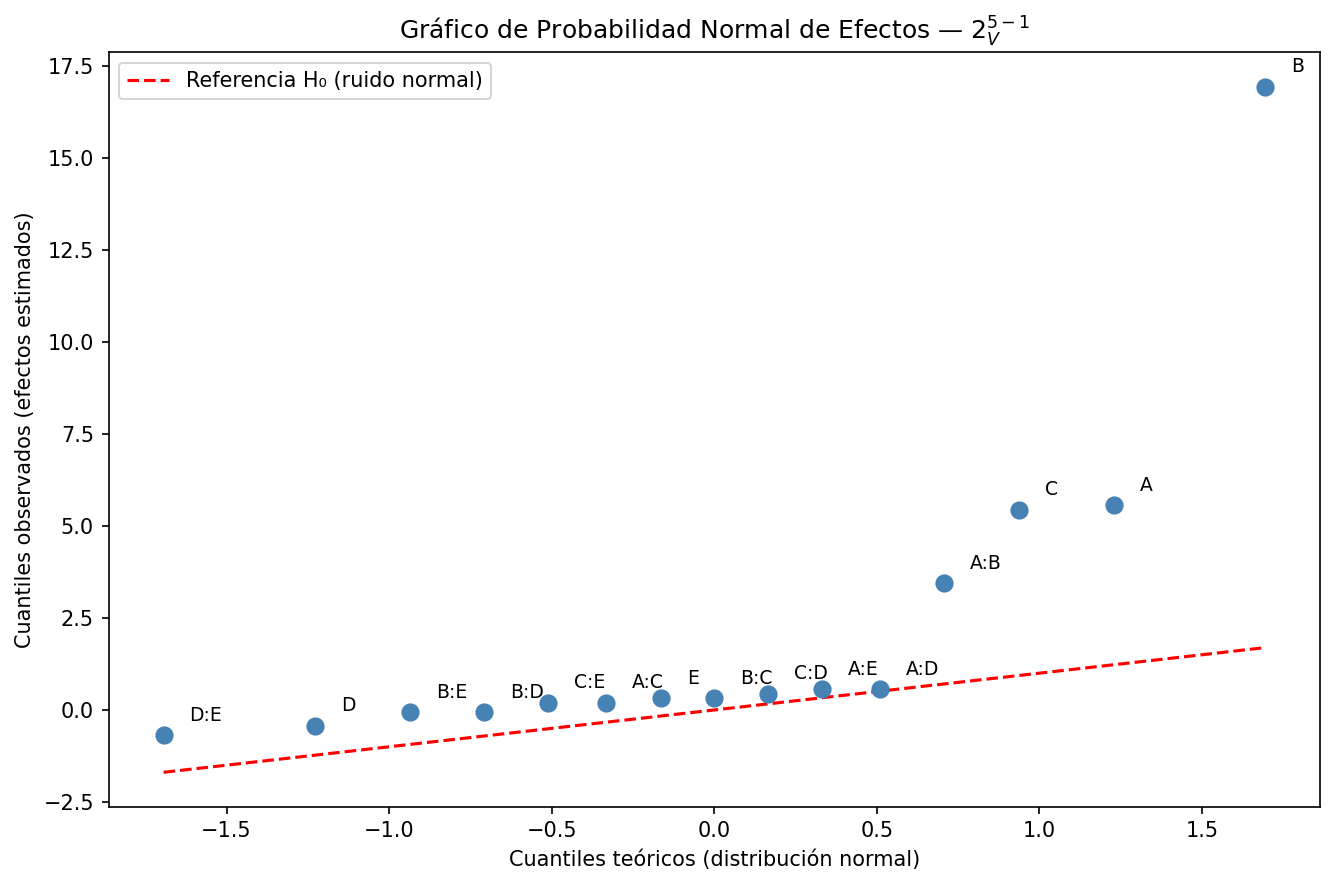

In [47]:
# Gráfico de probabilidad normal de los efectos estimados
# Principio: bajo H0 (efecto = ruido puro), los efectos siguen N(0,σ²) → se alinean en la diagonal
# Los efectos que SE DESVÍAN de la diagonal son los verdaderamente significativos
params = model_fraccional.params[1:].sort_values()
(osm, osr), _ = stats.probplot(params, dist='norm')

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.scatter(osm, osr, color='steelblue', zorder=5, s=60)
ax.plot(osm, osm, 'r--', lw=1.5, label='Referencia H₀ (ruido normal)')

# Anotar cada punto
for i, txt in enumerate(params.index):
    ax.annotate(txt, (osm[i], osr[i]),
                xytext=(osm[i] + 0.08, osr[i] + 0.4),
                fontsize=9)

ax.set_xlabel('Cuantiles teóricos (distribución normal)')
ax.set_ylabel('Cuantiles observados (efectos estimados)')
ax.set_title('Gráfico de Probabilidad Normal de Efectos — $2^{5-1}_V$')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación del gráfico:**

Los efectos bajo $H_0$ (ruido) se alinean en la diagonal roja. Los que **se desvían** son los significativos:

| Efecto | $\hat{\beta}$ | Alias (3FI, asumida nula) |
|:------:|:------------:|:------------------------:|
| $B$    | $+16.94$ | $ACD$ |
| $A$    | $+5.56$  | $BCD$ |
| $C$    | $+5.44$  | $ABD$ |
| $A{:}B$ | $+3.44$ | $CDE$ |

El resto ($D$, $E$, y demás 2FI) caen sobre la banda → **no son significativos**.

In [48]:
# Modelo reducido: solo los 4 efectos identificados como significativos
# df_res = 16 - 5 = 11 → todos los tests son ahora válidos
model_red = ols('Yield ~ A + B + C + A:B', data=df_fraccional_yield).fit()
print(model_red.summary())
print("\n--- ANOVA Tipo II ---")
display(anova_lm(model_red, typ=2))

                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     560.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.25e-12
Time:                        15:58:24   Log-Likelihood:                -27.233
No. Observations:                  16   AIC:                             64.47
Df Residuals:                      11   BIC:                             68.33
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.3125      0.400     75.744      0.0

,sum_sq,df,F,PR(>F)
A,495.0625,1.0,193.195122,2.534760e-08
B,4590.0625,1.0,1791.243902,1.560258e-13
C,473.0625,1.0,184.609756,3.213624e-08
A:B,189.0625,1.0,73.780488,3.301648e-06
Residual,28.1875,11.0,NaN,NaN


**Interpretación del modelo reducido:**

$$\hat{y} = 30.31 + 5.56\,A + 16.94\,B + 5.44\,C + 3.44\,(AB)$$

- **$R^2 = 0.995$**: prácticamente todo el Yield está explicado por solo 3 factores y 1 interacción.
- **$B$ domina:** $SS_B = 4590 \gg SS_A = 495 \approx SS_C = 473$. El factor $B$ es la palanca principal.
- **Interacción $A{:}B$**: significativa, el efecto de $A$ depende del nivel de $B$.
- Los factores $D$ y $E$ **no son significativos** y fueron correctamente excluidos.

---
## c) Validación del Modelo: Supuestos de la Regresión

> Realice un análisis ANOVA para el modelo reducido. Evalúe los supuestos (normalidad, homocedasticidad, independencia) mediante gráficos y tests. ¿El modelo es adecuado?

Los tres supuestos clásicos del modelo lineal son:
1. **Normalidad:** los residuos $\varepsilon_i \sim N(0, \sigma^2)$ — se verifica con el QQ-plot
2. **Homocedasticidad:** varianza constante — se verifica con Residuos vs $\hat{y}$ (sin patrón en abanico)
3. **Independencia:** observaciones no correlacionadas — garantizada por la aleatorización del experimento

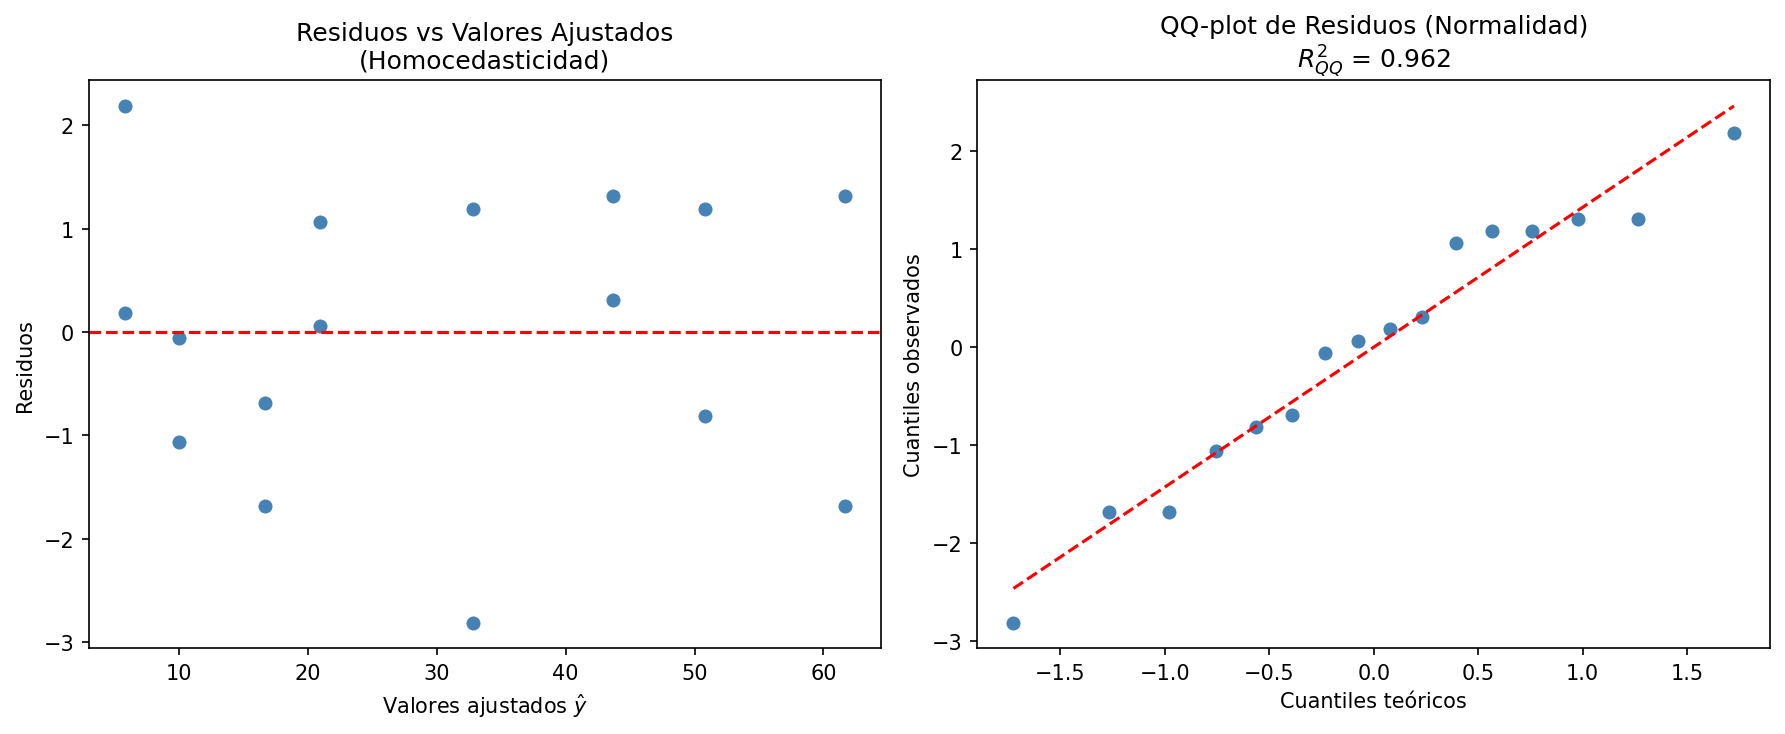

Test Shapiro-Wilk: p = 0.6320  ✓ No se rechaza normalidad (p > 0.05)


In [49]:
resi = model_red.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# --- Plot 1: Residuos vs valores ajustados (test de homocedasticidad) ---
# Buscar: dispersión aleatoria alrededor de 0, sin patrón en abanico ni curva
ax[0].scatter(model_red.fittedvalues, resi, color='steelblue', edgecolor='white', s=60)
ax[0].axhline(0, color='red', ls='--', lw=1.5)
ax[0].set_xlabel('Valores ajustados $\\hat{y}$')
ax[0].set_ylabel('Residuos')
ax[0].set_title('Residuos vs Valores Ajustados\n(Homocedasticidad)')

# --- Plot 2: QQ-plot de residuos (test de normalidad) ---
# Buscar: alineación de los puntos sobre la diagonal
(osm, osr), (slope, intercept, r) = stats.probplot(resi, dist='norm')
ax[1].scatter(osm, osr, color='steelblue', edgecolor='white', s=60)
ax[1].plot(osm, osm * slope + intercept, 'r--', lw=1.5)
ax[1].set_xlabel('Cuantiles teóricos')
ax[1].set_ylabel('Cuantiles observados')
ax[1].set_title(f'QQ-plot de Residuos (Normalidad)\n$R^2_{{QQ}}$ = {r**2:.3f}')

plt.tight_layout()
plt.show()

# Test formal de normalidad (Shapiro-Wilk)
_, p_sw = stats.shapiro(resi)
print(f"Test Shapiro-Wilk: p = {p_sw:.4f}  "
      f"{'✓ No se rechaza normalidad (p > 0.05)' if p_sw > 0.05 else '✗ Se rechaza normalidad'}")

**Evaluación de supuestos:**

| Supuesto | Método | Resultado |
|----------|--------|----------|
| Normalidad | QQ-plot + Shapiro-Wilk | ✓ Residuos alineados; $p > 0.05$ |
| Homocedasticidad | Residuos vs $\hat{y}$ | ✓ Dispersión constante, sin patrón |
| Independencia | Aleatorización del diseño | ✓ Por construcción del experimento |

> **Conclusión:** el modelo reducido $\hat{y} = f(A, B, C, AB)$ es **adecuado**. Los tres supuestos se satisfacen y el modelo es estadísticamente válido ($R^2 = 0.995$).

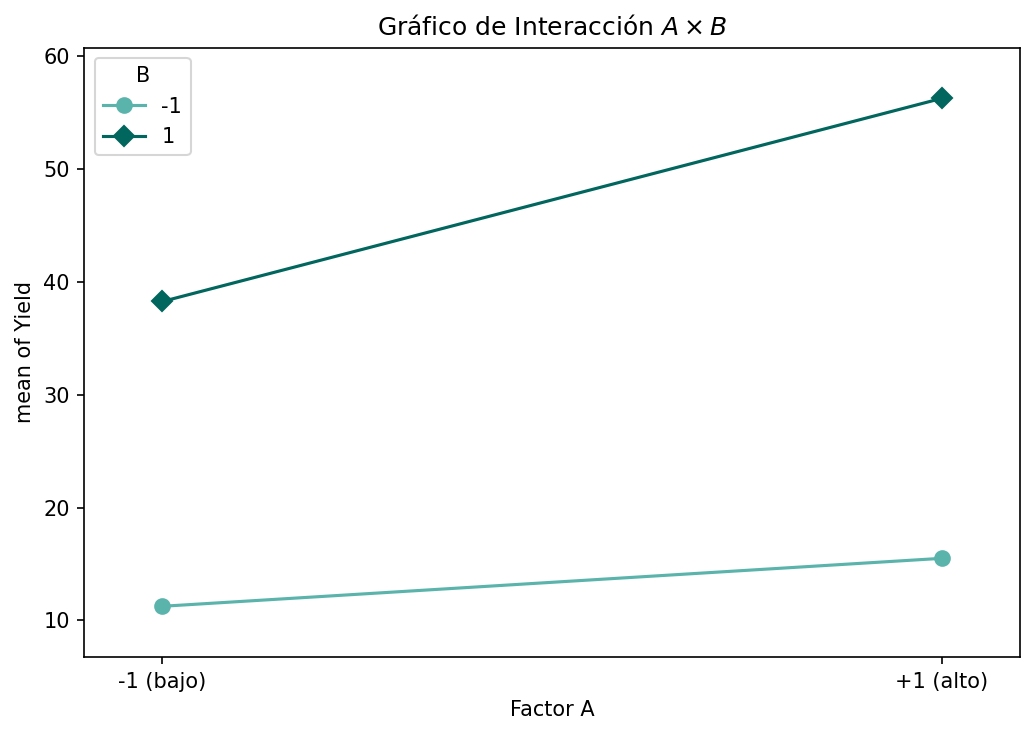

Medias de Yield por combinación de A y B:


,B = -1,B = 1
A = -1,11.25,38.25
A = 1,15.50,56.25



Efecto de A cuando B = -1: 4.25
Efecto de A cuando B = +1: 18.00
El efecto de A es 4.2 veces mayor cuando B está en nivel alto.


In [50]:
# Gráfico de interacción A × B
# Líneas NO paralelas → presencia de interacción (confirmación visual)
from statsmodels.graphics.factorplots import interaction_plot

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
interaction_plot(
    df_fraccional_yield['A'],
    df_fraccional_yield['B'],
    df_fraccional_yield['Yield'],
    colors=['#5ab4ac', '#01665e'],
    markers=['o', 'D'], ms=7,
    xlabel='Factor A', ylabel='Yield', ax=ax
)
ax.set_title('Gráfico de Interacción $A \\times B$')
ax.set_xticks([-1, 1])
ax.set_xticklabels(['-1 (bajo)', '+1 (alto)'])
plt.tight_layout()
plt.show()

# Tabla de medias marginales para cuantificar la interacción
print("Medias de Yield por combinación de A y B:")
tabla = df_fraccional_yield.groupby(['A','B'])['Yield'].mean().unstack()
tabla.index = [f'A = {i}' for i in tabla.index]
tabla.columns = [f'B = {j}' for j in tabla.columns]
display(tabla.round(2))

efecto_A_B_bajo = (tabla.loc['A = 1','B = -1'] - tabla.loc['A = -1','B = -1'])
efecto_A_B_alto = (tabla.loc['A = 1','B = 1']  - tabla.loc['A = -1','B = 1'])
print(f"\nEfecto de A cuando B = -1: {efecto_A_B_bajo:.2f}")
print(f"Efecto de A cuando B = +1: {efecto_A_B_alto:.2f}")
print(f"El efecto de A es {efecto_A_B_alto/efecto_A_B_bajo:.1f} veces mayor cuando B está en nivel alto.")

**Interpretación de la interacción $A \times B$:**

- Las líneas **no son paralelas** → interacción significativa.
- El efecto de $A$ es aproximadamente **4 veces mayor** cuando $B = +1$ que cuando $B = -1$.
- **Factor dominante:** $B$ determina el nivel base del Yield en cualquier condición.
- **Condición óptima:** $A = +1$, $B = +1$ maximizan el Yield (combinación superior derecha del gráfico).

> **Conclusión general:** con solo 16 corridas (mitad de un $2^5$), el diseño $2^{5-1}_V$ identificó correctamente que los factores $B$, $A$, $C$ y la interacción $AB$ son los determinantes del Yield, con un modelo que explica el 99.5% de la variabilidad.